# Logical Fallacy Classification — Progress 4 (Final)
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)  
https://github.com/Crowd-AI-Lab/cocolofa

**Progress 4 (Final):** BERT fine-tuning for logical fallacy classification.
- **Model:** `bert-base-uncased` (`BertForSequenceClassification`)
- **Input:** Article title (text\_a) + Comment (text\_b) — two-sequence BERT format; no traditional text preprocessing needed
- **Context:** Article title feeds BERT topic-level context; parent comment (if present) is prepended to the target comment
- **Key design choices:** Class-weighted cross-entropy loss (handles label imbalance), linear warmup scheduler, gradient clipping (max\_norm=1.0), best-checkpoint saving by val F1
- **Comparison:** Final test results compared against Progress 2 & 3 models

**Citation:**  
Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Install Dependencies

In [1]:
!pip install transformers -q
print("transformers installed.")

transformers installed.


## 1. Import Libraries

In [2]:
import json
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Libraries imported successfully!
PyTorch:        2.10.0+cu128
CUDA available: True
GPU:            Tesla T4


## 2. Configuration

In [3]:
# ── Paths 
KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'
DATA_DIR    = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else 'data'
print(f"Data directory: {DATA_DIR}")

# ── BERT / Training 
MODEL_NAME    = 'bert-base-uncased'
MAX_LENGTH    = 256          
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5
EPOCHS        = 4            
WARMUP_RATIO  = 0.06         # linear warmup over first 6 % of steps
WEIGHT_DECAY  = 0.01         # L2 regularisation via AdamW
GRAD_CLIP     = 1.0          # gradient clipping max-norm
SEED          = 42
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"\nModel:        {MODEL_NAME}")
print(f"Max length:   {MAX_LENGTH}  |  Batch size: {BATCH_SIZE}")
print(f"LR:           {LEARNING_RATE}  |  Epochs:     {EPOCHS}")
print(f"Warmup ratio: {WARMUP_RATIO}  |  Weight decay: {WEIGHT_DECAY}")
print(f"Device:       {DEVICE}")

Data directory: /kaggle/input/datasets/aristelcrowley/cocolofa

Model:        bert-base-uncased
Max length:   256  |  Batch size: 16
LR:           2e-05  |  Epochs:     4
Warmup ratio: 0.06  |  Weight decay: 0.01
Device:       cuda


## 3. Load Dataset

COCOLOFA's JSON files are structured as a list of **article** objects, each containing a `comments` list.  
Here we also extract the article **title** (context) and resolve **parent comments** for threaded replies.

In [4]:
def load_cocolofa(filepath):
    """Load a COCOLOFA JSON split and flatten into a DataFrame."""
    with open(filepath, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    records = []
    for article in raw:
        title = article.get('title', '')

        # Build a fast lookup so we can resolve parent comment text
        comment_lookup = {c['id']: c['comment'] for c in article.get('comments', [])}

        for comment in article.get('comments', []):
            parent_text = ''
            parent_id   = comment.get('parent_id')
            if parent_id and parent_id in comment_lookup:
                parent_text = comment_lookup[parent_id]

            records.append({
                'comment_id':     comment['id'],
                'news_id':        comment['news_id'],
                'fallacy':        comment['fallacy'],
                'comment':        comment['comment'],
                'title':          title,
                'parent_comment': parent_text,
            })

    return pd.DataFrame(records)


df      = load_cocolofa(os.path.join(DATA_DIR, 'train.json'))
df_test = load_cocolofa(os.path.join(DATA_DIR, 'test.json'))

print(f"Train comments : {len(df)}")
print(f"Test  comments : {len(df_test)}")
print(f"\nFallacy distribution (train):")
print(df['fallacy'].value_counts())

Train comments : 5370
Test  comments : 798

Fallacy distribution (train):
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64


## 4. Prepare BERT Input (Title + Comment — No Traditional Preprocessing)

BERT's WordPiece tokenizer handles casing, punctuation, and sub-word splitting internally —  
classical cleaning (lowercasing, lemmatisation, stopword removal) is **not needed** and can  
actually discard signal.

**Two-sequence format used:**  
`[CLS]` article title `[SEP]` (parent comment. ) target comment `[SEP]`

- **Segment A (token\_type\_ids = 0):** article title — gives BERT topic-level context  
- **Segment B (token\_type\_ids = 1):** comment (optionally prefixed with parent comment)

In [5]:
def build_context_comment(row):
    """Prepend parent comment to the target comment when available."""
    if row['parent_comment']:
        return row['parent_comment'] + '. ' + row['comment']
    return row['comment']


df['input_comment']      = df.apply(build_context_comment, axis=1)
df_test['input_comment'] = df_test.apply(build_context_comment, axis=1)

print("Input preparation complete (no traditional preprocessing applied).")
print(f"\nExample:")
print(f"  Title   : {df['title'].iloc[0][:90]}...")
print(f"  Comment : {df['input_comment'].iloc[0][:90]}...")

Input preparation complete (no traditional preprocessing applied).

Example:
  Title   : Even with a law, São Paulo's municipalities are not fulfilling citizens’ right of access t...
  Comment : Lack of transparency in government isn't unexpected.  No one likes to be under scrutiny,  ...


## 5. Label Encoding

In [6]:
label_encoder = LabelEncoder()
df['label']      = label_encoder.fit_transform(df['fallacy'])
df_test['label'] = label_encoder.transform(df_test['fallacy'])

NUM_CLASSES = len(label_encoder.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls:<30s} ({count:4d} samples)")

Number of classes: 9

Label mapping:
  0 → appeal to authority            ( 350 samples)
  1 → appeal to majority             ( 383 samples)
  2 → appeal to nature               ( 412 samples)
  3 → appeal to tradition            ( 401 samples)
  4 → appeal to worse problems       ( 421 samples)
  5 → false dilemma                  ( 391 samples)
  6 → hasty generalization           ( 379 samples)
  7 → none                           (2202 samples)
  8 → slippery slope                 ( 431 samples)


## 6. Class Weights (Handle Label Imbalance)

The `none` class (~40 % of training data) heavily outnumbers individual fallacy types.  
Computing `balanced` class weights and passing them to `CrossEntropyLoss` penalises  
misclassifications of minority classes more strongly — critical for high F1 across all types.

In [7]:
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=df['label'].values,
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(DEVICE)

print("Class weights:")
for cls, w in zip(label_encoder.classes_, class_weights_np):
    print(f"  {cls:<30s} → {w:.4f}")

Class weights:
  appeal to authority            → 1.7048
  appeal to majority             → 1.5579
  appeal to nature               → 1.4482
  appeal to tradition            → 1.4879
  appeal to worse problems       → 1.4173
  false dilemma                  → 1.5260
  hasty generalization           → 1.5743
  none                           → 0.2710
  slippery slope                 → 1.3844


## 7. Train / Val / Test Split (85 / 15 from train.json + fixed test.json)

In [8]:
df_train, df_val = train_test_split(
    df,
    test_size=0.15,
    random_state=SEED,
    stratify=df['label'],
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train : {len(df_train):5d} samples")
print(f"Val   : {len(df_val):5d} samples")
print(f"Test  : {len(df_test):5d} samples")

Train :  4564 samples
Val   :   806 samples
Test  :   798 samples


## 8. Tokenization & PyTorch Dataset

In [9]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")


class FallacyDataset(Dataset):
    """PyTorch Dataset — wraps BERT tokenisation for (title, comment) pairs."""

    def __init__(self, dataframe, tokenizer, max_length):
        self.titles    = dataframe['title'].tolist()
        self.comments  = dataframe['input_comment'].tolist()
        self.labels    = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.titles[idx],    # text_a — article title (segment A)
            self.comments[idx],  # text_b — (parent +) comment (segment B)
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = FallacyDataset(df_train, tokenizer, MAX_LENGTH)
val_dataset   = FallacyDataset(df_val,   tokenizer, MAX_LENGTH)
test_dataset  = FallacyDataset(df_test,  tokenizer, MAX_LENGTH)

print(f"Datasets created — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased
Datasets created — Train: 4564 | Val: 806 | Test: 798


## 9. DataLoaders

In [10]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"DataLoaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Test  batches : {len(test_loader)}")

DataLoaders ready.
  Train batches : 286
  Val   batches : 51
  Test  batches : 50


## 10. Model Setup (BertForSequenceClassification)

In [11]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model : {MODEL_NAME}")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Output classes       : {NUM_CLASSES}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model : bert-base-uncased
  Total parameters     : 109,489,161
  Trainable parameters : 109,489,161
  Output classes       : 9


## 11. Optimizer & Scheduler

- **AdamW** with `weight_decay=0.01` (L2 regularisation applied to all non-bias parameters)  
- **Linear warmup** over the first 6 % of training steps, then linear decay to 0  
- **Weighted CrossEntropyLoss** to up-weight minority fallacy classes

In [12]:
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eps=1e-8,
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print(f"Optimizer : AdamW  (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler : Linear warmup — {warmup_steps} warmup / {total_steps} total steps")
print(f"Loss      : CrossEntropyLoss with balanced class weights")

Optimizer : AdamW  (lr=2e-05, weight_decay=0.01)
Scheduler : Linear warmup — 68 warmup / 1144 total steps
Loss      : CrossEntropyLoss with balanced class weights


## 12. Training Loop

In [13]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1_w     = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1_w


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )
            loss = loss_fn(outputs.logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1_w     = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1_w, all_preds, all_labels


print("train_epoch and eval_epoch defined.")

train_epoch and eval_epoch defined.


In [14]:
# ── Run Training
CHECKPOINT = '/kaggle/working/best_bert_p4.pt'

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1':   [],
}
best_val_f1 = 0.0
best_epoch  = 0

header = f"{'Epoch':^6} {'Tr Loss':^9} {'Tr Acc':^9} {'Tr F1':^9} | {'Va Loss':^9} {'Va Acc':^9} {'Va F1':^9}"
print('=' * len(header))
print(header)
print('=' * len(header))

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    va_loss, va_acc, va_f1, _, _ = eval_epoch(model, val_loader, loss_fn, DEVICE)

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc); history['train_f1'].append(tr_f1)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc);   history['val_f1'].append(va_f1)

    marker = '  ← best' if va_f1 > best_val_f1 else ''
    print(
        f"{epoch:^6} {tr_loss:^9.4f} {tr_acc:^9.4f} {tr_f1:^9.4f} | "
        f"{va_loss:^9.4f} {va_acc:^9.4f} {va_f1:^9.4f}{marker}"
    )

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        best_epoch  = epoch
        torch.save(model.state_dict(), CHECKPOINT)

print('=' * len(header))
print(f"Best model: Epoch {best_epoch}  |  Val F1 (weighted): {best_val_f1:.4f}")

Epoch   Tr Loss   Tr Acc     Tr F1   |  Va Loss   Va Acc     Va F1  
  1     1.9367    0.2250    0.2032   |  1.1856    0.4392    0.3549    ← best
  2     0.7918    0.6304    0.6119   |  0.7227    0.6687    0.6664    ← best
  3     0.4535    0.7816    0.7797   |  0.6900    0.7022    0.6976    ← best
  4     0.3018    0.8501    0.8500   |  0.6913    0.7122    0.7102    ← best
Best model: Epoch 4  |  Val F1 (weighted): 0.7102


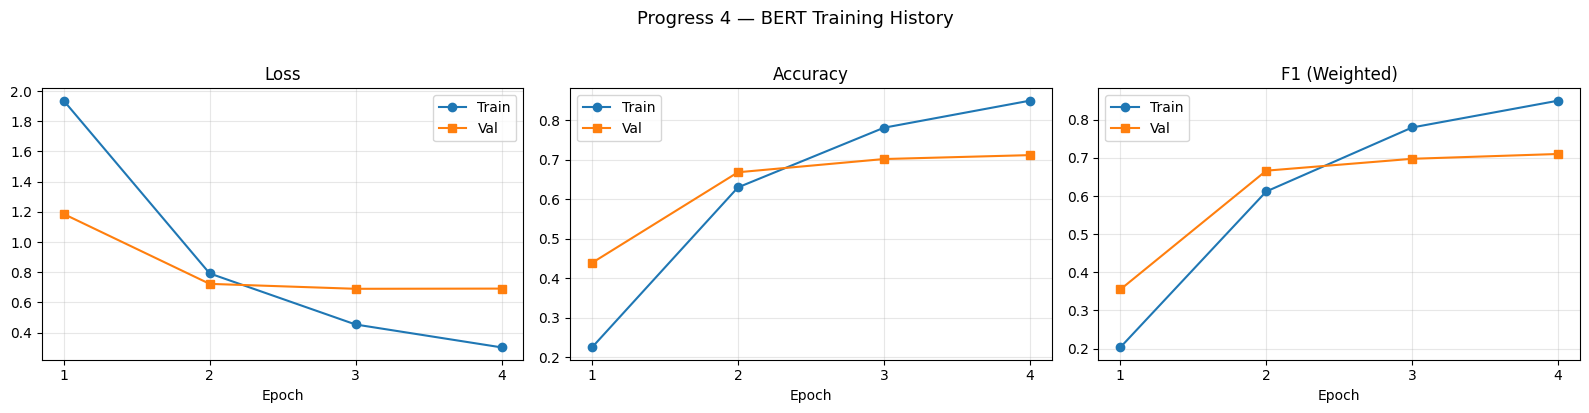

In [15]:
# ── Training History Plot 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_x = range(1, EPOCHS + 1)

for ax, metric, title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc'), ('train_f1', 'val_f1')],
    ['Loss', 'Accuracy', 'F1 (Weighted)'],
):
    ax.plot(epochs_x, history[metric[0]], marker='o', label='Train')
    ax.plot(epochs_x, history[metric[1]], marker='s', label='Val')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_xticks(epochs_x)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Progress 4 — BERT Training History', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. Test Evaluation

In [16]:
# Load the best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
print(f"Best checkpoint loaded (Epoch {best_epoch}).")

_, test_acc, test_f1_w, y_pred, y_true = eval_epoch(model, test_loader, loss_fn, DEVICE)

test_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_recall    = recall_score(y_true,    y_pred, average='weighted', zero_division=0)
test_f1_macro  = f1_score(y_true,        y_pred, average='macro',    zero_division=0)

print(f"\n{'='*50}")
print(f"  TEST RESULTS — BERT (Best epoch: {best_epoch})")
print(f"{'='*50}")
print(f"  Accuracy          : {test_acc:.4f}")
print(f"  Precision (W)     : {test_precision:.4f}")
print(f"  Recall    (W)     : {test_recall:.4f}")
print(f"  F1 (Weighted)     : {test_f1_w:.4f}")
print(f"  F1 (Macro)        : {test_f1_macro:.4f}")
print(f"{'='*50}")

Best checkpoint loaded (Epoch 4).

  TEST RESULTS — BERT (Best epoch: 4)
  Accuracy          : 0.7343
  Precision (W)     : 0.7471
  Recall    (W)     : 0.7343
  F1 (Weighted)     : 0.7306
  F1 (Macro)        : 0.7537


## 14. Per-Class Metrics (Best BERT Model)

In [17]:
report_dict = classification_report(
    y_true, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)

per_class_rows = []
for cls in label_encoder.classes_:
    per_class_rows.append({
        'Fallacy Type': cls,
        'Precision':    report_dict[cls]['precision'],
        'Recall':       report_dict[cls]['recall'],
        'F1-Score':     report_dict[cls]['f1-score'],
        'Support':      int(report_dict[cls]['support']),
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
per_class_df.index += 1

print(f"  Per-Class F1 Scores — BERT (Test Set)")
display(per_class_df.style.format({
    'Precision': '{:.4f}',
    'Recall':    '{:.4f}',
    'F1-Score':  '{:.4f}',
    'Support':   '{:.0f}',
}).background_gradient(subset=['F1-Score'], cmap='Greens'))

  Per-Class F1 Scores — BERT (Test Set)


,Fallacy Type,Precision,Recall,F1-Score,Support
1,appeal to nature,0.8125,0.9455,0.8739,55
2,appeal to majority,0.7639,0.9322,0.8397,59
3,appeal to tradition,0.7571,0.8983,0.8217,59
4,slippery slope,0.7667,0.8846,0.8214,78
5,appeal to worse problems,0.7467,0.8750,0.8058,64
6,appeal to authority,0.6986,0.9107,0.7907,56
7,false dilemma,0.7959,0.7800,0.7879,50
8,none,0.8060,0.5899,0.6812,317
9,hasty generalization,0.3288,0.4000,0.3609,60


## 15. Confusion Matrix

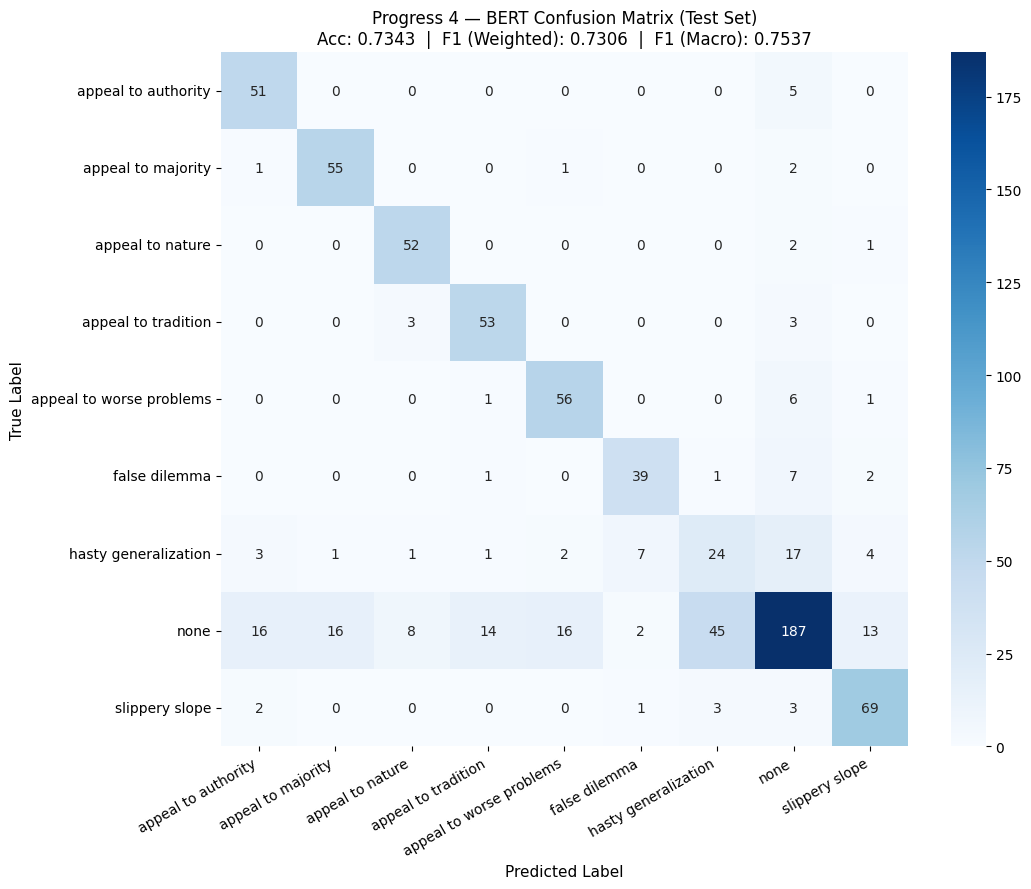

In [18]:
fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
ax.set_title(
    f'Progress 4 — BERT Confusion Matrix (Test Set)\n'
    f'Acc: {test_acc:.4f}  |  F1 (Weighted): {test_f1_w:.4f}  |  F1 (Macro): {test_f1_macro:.4f}',
    fontsize=12,
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 16. Save Model

In [19]:
SAVE_DIR = '/kaggle/working/models/progress_4'
os.makedirs(SAVE_DIR, exist_ok=True)

# HuggingFace format (config + weights)
model.save_pretrained(os.path.join(SAVE_DIR, 'bert_model'))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, 'bert_tokenizer'))

# Label encoder & metadata
joblib.dump(label_encoder, os.path.join(SAVE_DIR, 'label_encoder.joblib'))
joblib.dump({
    'model_name':  MODEL_NAME,
    'max_length':  MAX_LENGTH,
    'num_classes': NUM_CLASSES,
    'best_epoch':  best_epoch,
    'val_f1':      best_val_f1,
    'hyperparams': {
        'lr':           LEARNING_RATE,
        'epochs':       EPOCHS,
        'batch_size':   BATCH_SIZE,
        'max_length':   MAX_LENGTH,
        'warmup_ratio': WARMUP_RATIO,
        'weight_decay': WEIGHT_DECAY,
        'grad_clip':    GRAD_CLIP,
    },
    'test_metrics': {
        'accuracy':           test_acc,
        'precision_weighted': test_precision,
        'recall_weighted':    test_recall,
        'f1_weighted':        test_f1_w,
        'f1_macro':           test_f1_macro,
    },
}, os.path.join(SAVE_DIR, 'model_info.joblib'))

print(f"All artefacts saved to  {SAVE_DIR}/")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  - {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All artefacts saved to  /kaggle/working/models/progress_4/
  - bert_model
  - bert_tokenizer
  - label_encoder.joblib
  - model_info.joblib


## 17. Summary

In [20]:
print("  PROGRESS 4 — BERT FINE-TUNING SUMMARY")
print()
print(f"Model            : {MODEL_NAME}")
print(f"Input format     : [CLS] article title [SEP] (parent. ) comment [SEP]")
print()
print("Hyperparameters:")
print(f"  Max length     : {MAX_LENGTH}  (title + comment; longer than typical 128)")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Learning rate  : {LEARNING_RATE}")
print(f"  Epochs         : {EPOCHS}  (best: {best_epoch})")
print(f"  Warmup ratio   : {WARMUP_RATIO}  ({warmup_steps} warmup steps)")
print(f"  Weight decay   : {WEIGHT_DECAY}")
print(f"  Gradient clip  : {GRAD_CLIP}")
print(f"  Loss           : CrossEntropyLoss + balanced class weights")
print()
print(f"Data split:")
print(f"  Train          : {len(df_train):5d} samples")
print(f"  Val            : {len(df_val):5d} samples")
print(f"  Test           : {len(df_test):5d} samples")
print()
print("Test results:")
print(f"  {'Metric':<22} {'Score':>8}")
print(f"  {'-'*32}")
print(f"  {'Accuracy':<22} {test_acc:>8.4f}")
print(f"  {'Precision (Weighted)':<22} {test_precision:>8.4f}")
print(f"  {'Recall (Weighted)':<22} {test_recall:>8.4f}")
print(f"  {'F1 (Weighted)':<22} {test_f1_w:>8.4f}")
print(f"  {'F1 (Macro)':<22} {test_f1_macro:>8.4f}")
print()
print(f"Model saved to   : {SAVE_DIR}/")

  PROGRESS 4 — BERT FINE-TUNING SUMMARY

Model            : bert-base-uncased
Input format     : [CLS] article title [SEP] (parent. ) comment [SEP]

Hyperparameters:
  Max length     : 256  (title + comment; longer than typical 128)
  Batch size     : 16
  Learning rate  : 2e-05
  Epochs         : 4  (best: 4)
  Warmup ratio   : 0.06  (68 warmup steps)
  Weight decay   : 0.01
  Gradient clip  : 1.0
  Loss           : CrossEntropyLoss + balanced class weights

Data split:
  Train          :  4564 samples
  Val            :   806 samples
  Test           :   798 samples

Test results:
  Metric                    Score
  --------------------------------
  Accuracy                 0.7343
  Precision (Weighted)     0.7471
  Recall (Weighted)        0.7343
  F1 (Weighted)            0.7306
  F1 (Macro)               0.7537

Model saved to   : /kaggle/working/models/progress_4/


## 18. Local Inference (Single Input)

Load the saved model and run inference on an arbitrary (title, comment) pair.

In [21]:
import joblib
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# ── Load saved artefacts 
_SAVE_DIR   = '/kaggle/working/models/progress_4'
_inf_model  = BertForSequenceClassification.from_pretrained(f'{_SAVE_DIR}/bert_model')
_tokenizer  = BertTokenizer.from_pretrained(f'{_SAVE_DIR}/bert_tokenizer')
_le         = joblib.load(f'{_SAVE_DIR}/label_encoder.joblib')
_info       = joblib.load(f'{_SAVE_DIR}/model_info.joblib')
_inf_model.eval()

_MAX_LEN = _info['max_length']


def predict_fallacy(title: str, comment: str) -> tuple[str, float]:
    """
    Predict the logical fallacy type for a (title, comment) pair.

    Parameters
    ----------
    title   : article headline that provides topic context
    comment : the comment text to classify

    Returns
    -------
    (predicted_label, confidence_score)
    """
    enc = _tokenizer(
        title,
        comment,
        max_length=_MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    with torch.no_grad():
        logits = _inf_model(**enc).logits
        probs  = torch.softmax(logits, dim=1).squeeze(0)
        pred   = torch.argmax(probs).item()

    label      = _le.inverse_transform([pred])[0]
    confidence = probs[pred].item()
    return label, confidence


# ── Test examples 
examples = [
    (
        "New abortion laws passed in state legislature",
        "If we allow abortion, next they will allow euthanasia, and then murder will become legal.",
    ),
    (
        "Scientists call for action on climate change",
        "All environmentalists are just trying to destroy the economy — they are all the same.",
    ),
    (
        "Government proposes new immigration policy",
        "We have always done things this way, and it has worked fine. There is no reason to change it now.",
    ),
]

print(f"{'─'*70}")
print(f"{'Title':<35} {'Predicted Label':<25} {'Confidence':>10}")
print(f"{'─'*70}")
for title, comment in examples:
    label, conf = predict_fallacy(title, comment)
    print(f"{title[:34]:<35} {label:<25} {conf:>10.4f}")
    print(f"  Comment: {comment[:80]}...")
    print()
print(f"{'─'*70}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

──────────────────────────────────────────────────────────────────────
Title                               Predicted Label           Confidence
──────────────────────────────────────────────────────────────────────
New abortion laws passed in state   slippery slope                0.9542
  Comment: If we allow abortion, next they will allow euthanasia, and then murder will beco...

Scientists call for action on clim  hasty generalization          0.5521
  Comment: All environmentalists are just trying to destroy the economy — they are all the ...

Government proposes new immigratio  appeal to tradition           0.9674
  Comment: We have always done things this way, and it has worked fine. There is no reason ...

──────────────────────────────────────────────────────────────────────
